In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [4]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense,Input
import numpy as np

# 머신러닝 / 딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨인식, 문장분류, 질병진단, ...
※ ML/DL의 종류
- 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
    회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
- 비지도학습(입력변수만)
    군집화
- 강화학습

※ 지도학습에서의 ML, DL 프로그래밍 방식
1. 데이터 셋 확보(input=입력변수, target=종속변수)
    원본 데이터 및 시물레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈력셋(학습셋), 검증셋, 시험셋(테스트셋) = 7: 2: 1
    학습 및 평가 가능한 포맷으로 변환(numpy, DataFrame)
3. 모델 구성
    Sequential 객체 생성뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    compile()함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델 학습시키기 (ft. 학습과정 지켜 보기)
    fit()함수 이용 - 훈련셋입력=독립변수, 훈련셋타겟=종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프
7. 모델 사용
    predict()함수 이용. 입력데이터는 2차원 데이터
8. 모델 저장
    save()함수 이용해서 저장. 저장된 모델은 load_model()함수를 이용해서 불러올 수 있음

# 1. 데이터 셋 생성
# 2. 데이터 전처리

In [6]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,12,16,18]*10)
# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,12,16,18])
# 테스트 데이터 셋 = 시험데이터
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,12,16,18])
x_train.shape, x_val.shape, x_test.shape, y_train.shape, y_val.shape, y_test.shape

((90,), (9,), (9,), (90,), (9,), (9,))

In [12]:
# 인코딩 종류
data = np.array(['a', 'b', 'c', 'd'])
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeled_data = le.transform(data)
labeled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labeled_data)
one_hot_encoded = to_categorical(labeled_data)
print('원핫인코딩된 데이터 :', one_hot_encoded)

원 데이터 : ['a' 'b' 'c' 'd']
라벨인코딩된 데이터 : [0 1 2 3]
원핫인코딩된 데이터 : [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [15]:
# 분류분석을 하기위해, target을 원핫인코딩(라벨링 전환)
data = np.array([1,2,2,4,2])
print(data)
cagorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n', cagorical_one_hot)
import pandas as pd
get_dumies_one_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩 :', get_dumies_one_hot)
print(type(get_dumies_one_hot))

[1 2 2 4 2]
to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'pandas.core.frame.DataFrame'>


In [20]:
# 분류분석을 위한 target변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train)
Y_val   = to_categorical(y_val)
Y_test  = to_categorical(y_test)


In [23]:
print('훈련데이터셋 구조 :', x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19
print('검증데이터셋 구조 :', x_val.shape, Y_val.shape)
print('테스트데이터셋 구조 :', x_test.shape, Y_test.shape)

훈련데이터셋 구조 : (90,) (90, 19)
검증데이터셋 구조 : (9,) (9, 19)
테스트데이터셋 구조 : (9,) (9, 19)


# 3. 모델 구성하기

In [24]:
model = Sequential()
model.add(Input(shape=(1,))) # 입력층
model.add(Dense(units=38, activation='sigmoid')) # units출력수, 활성화함수:relu, thnh, 
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))   
    # 출력층, softmax: 모든 출력결과의 합이 1. 분류분석 마지막 layer(출력층)에서 activation으로
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [25]:
model.compile(loss='categorical_crossentropy', # 분류분석에서의 손실함수(원핫인코딩 有)
             optimizer='sgd',
             metrics=['accuracy']) # 평가지표 : accuracy

# 5. 모델 학습시키기

In [26]:
hist = model.fit(x_train, Y_train,
                epochs = 300,
                batch_size=10,
                verbose=2, # 학습결과 출력 옵션 0: 출력없음, 1: 기본값, 2: 에포크별로 로그 상세출력
                validation_data=(x_val, Y_val)
                )

Epoch 1/300
9/9 - 1s - loss: 2.8612 - accuracy: 0.0667 - val_loss: 2.7411 - val_accuracy: 0.0000e+00 - 676ms/epoch - 75ms/step
Epoch 2/300
9/9 - 0s - loss: 2.6821 - accuracy: 0.1889 - val_loss: 2.5975 - val_accuracy: 0.2222 - 54ms/epoch - 6ms/step
Epoch 3/300
9/9 - 0s - loss: 2.5623 - accuracy: 0.2222 - val_loss: 2.4971 - val_accuracy: 0.2222 - 45ms/epoch - 5ms/step
Epoch 4/300
9/9 - 0s - loss: 2.4749 - accuracy: 0.2222 - val_loss: 2.4227 - val_accuracy: 0.2222 - 43ms/epoch - 5ms/step
Epoch 5/300
9/9 - 0s - loss: 2.4090 - accuracy: 0.2222 - val_loss: 2.3609 - val_accuracy: 0.2222 - 45ms/epoch - 5ms/step
Epoch 6/300
9/9 - 0s - loss: 2.3500 - accuracy: 0.2222 - val_loss: 2.3074 - val_accuracy: 0.2222 - 46ms/epoch - 5ms/step
Epoch 7/300
9/9 - 0s - loss: 2.2969 - accuracy: 0.2222 - val_loss: 2.2594 - val_accuracy: 0.2222 - 42ms/epoch - 5ms/step
Epoch 8/300
9/9 - 0s - loss: 2.2532 - accuracy: 0.2222 - val_loss: 2.2174 - val_accuracy: 0.2222 - 45ms/epoch - 5ms/step
Epoch 9/300
9/9 - 0s - los

Epoch 69/300
9/9 - 0s - loss: 1.3799 - accuracy: 0.4444 - val_loss: 1.3517 - val_accuracy: 0.5556 - 45ms/epoch - 5ms/step
Epoch 70/300
9/9 - 0s - loss: 1.3742 - accuracy: 0.5000 - val_loss: 1.3417 - val_accuracy: 0.4444 - 45ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.3655 - accuracy: 0.4556 - val_loss: 1.3312 - val_accuracy: 0.5556 - 44ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.3538 - accuracy: 0.5556 - val_loss: 1.3236 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 73/300
9/9 - 0s - loss: 1.3462 - accuracy: 0.4556 - val_loss: 1.3131 - val_accuracy: 0.4444 - 41ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.3317 - accuracy: 0.5111 - val_loss: 1.3027 - val_accuracy: 0.5556 - 45ms/epoch - 5ms/step
Epoch 75/300
9/9 - 0s - loss: 1.3218 - accuracy: 0.5667 - val_loss: 1.2968 - val_accuracy: 0.4444 - 44ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.3063 - accuracy: 0.5556 - val_loss: 1.2840 - val_accuracy: 0.4444 - 45ms/epoch - 5ms/step
Epoch 77/300
9/9 - 0s - 

Epoch 136/300
9/9 - 0s - loss: 0.8875 - accuracy: 0.8667 - val_loss: 0.8657 - val_accuracy: 0.7778 - 40ms/epoch - 4ms/step
Epoch 137/300
9/9 - 0s - loss: 0.8834 - accuracy: 0.7667 - val_loss: 0.8602 - val_accuracy: 0.7778 - 42ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 0.8757 - accuracy: 0.8000 - val_loss: 0.8531 - val_accuracy: 0.8889 - 45ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 0.8798 - accuracy: 0.7778 - val_loss: 0.8476 - val_accuracy: 0.7778 - 44ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 0.8787 - accuracy: 0.8222 - val_loss: 0.8427 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 141/300
9/9 - 0s - loss: 0.8605 - accuracy: 0.8222 - val_loss: 0.8361 - val_accuracy: 0.7778 - 45ms/epoch - 5ms/step
Epoch 142/300
9/9 - 0s - loss: 0.8680 - accuracy: 0.7667 - val_loss: 0.8309 - val_accuracy: 0.7778 - 44ms/epoch - 5ms/step
Epoch 143/300
9/9 - 0s - loss: 0.8494 - accuracy: 0.8000 - val_loss: 0.8289 - val_accuracy: 0.8889 - 47ms/epoch - 5ms/step
Epoch 144/300
9/

Epoch 203/300
9/9 - 0s - loss: 0.5928 - accuracy: 0.9556 - val_loss: 0.5698 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 204/300
9/9 - 0s - loss: 0.5954 - accuracy: 0.9111 - val_loss: 0.5675 - val_accuracy: 1.0000 - 47ms/epoch - 5ms/step
Epoch 205/300
9/9 - 0s - loss: 0.5893 - accuracy: 0.9444 - val_loss: 0.5729 - val_accuracy: 0.7778 - 43ms/epoch - 5ms/step
Epoch 206/300
9/9 - 0s - loss: 0.5828 - accuracy: 0.8889 - val_loss: 0.5594 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 207/300
9/9 - 0s - loss: 0.5807 - accuracy: 0.9000 - val_loss: 0.5604 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 208/300
9/9 - 0s - loss: 0.5869 - accuracy: 0.9667 - val_loss: 0.5606 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 209/300
9/9 - 0s - loss: 0.5713 - accuracy: 0.9333 - val_loss: 0.5501 - val_accuracy: 1.0000 - 39ms/epoch - 4ms/step
Epoch 210/300
9/9 - 0s - loss: 0.5604 - accuracy: 0.9556 - val_loss: 0.5469 - val_accuracy: 1.0000 - 45ms/epoch - 5ms/step
Epoch 211/300
9/

Epoch 270/300
9/9 - 0s - loss: 0.4162 - accuracy: 0.9111 - val_loss: 0.3825 - val_accuracy: 1.0000 - 41ms/epoch - 5ms/step
Epoch 271/300
9/9 - 0s - loss: 0.3922 - accuracy: 1.0000 - val_loss: 0.3785 - val_accuracy: 1.0000 - 48ms/epoch - 5ms/step
Epoch 272/300
9/9 - 0s - loss: 0.3986 - accuracy: 0.9778 - val_loss: 0.3847 - val_accuracy: 1.0000 - 32ms/epoch - 4ms/step
Epoch 273/300
9/9 - 0s - loss: 0.3844 - accuracy: 0.9889 - val_loss: 0.3715 - val_accuracy: 1.0000 - 55ms/epoch - 6ms/step
Epoch 274/300
9/9 - 0s - loss: 0.3919 - accuracy: 0.9778 - val_loss: 0.3698 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 275/300
9/9 - 0s - loss: 0.3870 - accuracy: 0.9778 - val_loss: 0.3688 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 276/300
9/9 - 0s - loss: 0.3860 - accuracy: 0.9778 - val_loss: 0.3679 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 277/300
9/9 - 0s - loss: 0.3775 - accuracy: 0.9778 - val_loss: 0.3630 - val_accuracy: 1.0000 - 43ms/epoch - 5ms/step
Epoch 278/300
9/

# 6. 모델 평가하기(모델학습과정 살펴보기, evaluate)

In [27]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

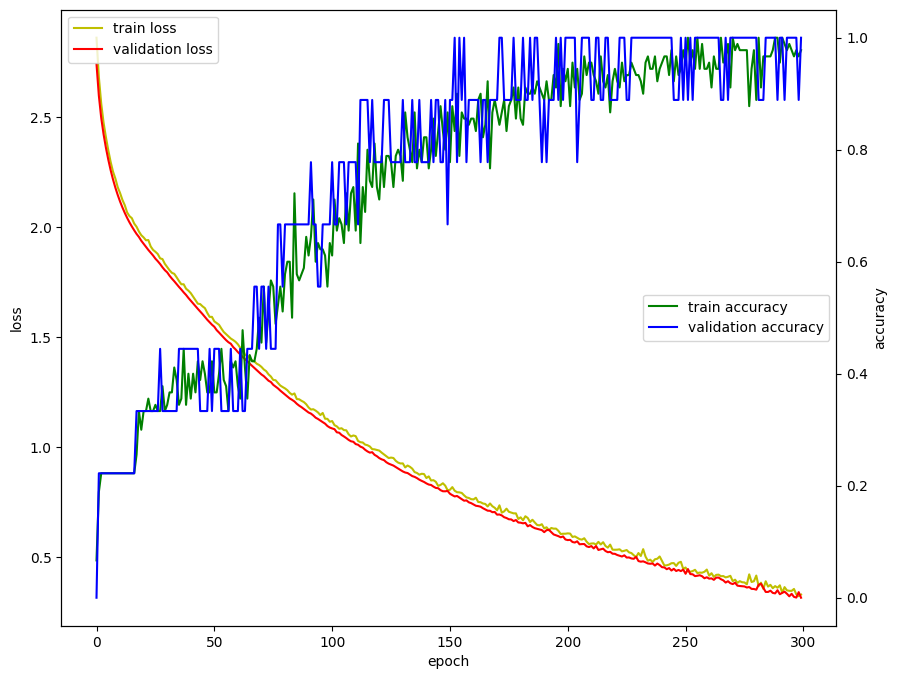

In [29]:
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,8))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='validation loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax생성

acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='validation accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [30]:
# 모델 평가
score = model.evaluate(x_test, Y_test, batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.3166 - accuracy: 1.0000


In [31]:
score # loss, accuracy

[0.31663915514945984, 1.0]

In [33]:
print('평가된 loss :', score[0])
print('평가된 accuracy', score[1]*100, '%')

평가된 loss : 0.31663915514945984
평가된 accuracy 100.0 %


In [34]:
# 7. 모델 사용하기
H = model.predict(np.array([[2]]))

1/1 [==============================] - 0s 112ms/step


array([[1.30959137e-14, 3.47245600e-11, 7.71052763e-02, 1.85882586e-13,
        8.19621027e-01, 2.15687344e-08, 1.02647685e-01, 3.32004846e-09,
        6.25816698e-04, 1.49412902e-14, 1.81951421e-07, 1.50960776e-12,
        1.80997177e-12, 6.34086950e-11, 2.42845632e-10, 6.53339674e-11,
        1.78703363e-19, 8.95892925e-14, 4.79563027e-27]], dtype=float32)

In [35]:
# 분류분석의 예측은 predict()후 argmax()
model.predict(np.array([[2]])).argmax()


1/1 [==============================] - 0s 29ms/step


4

In [36]:
# 4를 몇%확률로 예측했는지?
H[0,H.argmax()]*100

81.96210265159607

# 7. 모델 저장하기

In [37]:
model.save('model/02_deep.h5')

In [38]:
# from tensorflow.keras.models import save_model
# save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [24]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense,Input
import numpy as np

model2 = load_model('model/02_deep.h5')

In [25]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


In [26]:
data = np.array([[2],
                [3]])
preditions = model2.predict(data)
preditions.argmax(axis=1)

1/1 [==============================] - 0s 62ms/step


array([4, 6], dtype=int64)

In [27]:
def predict_classes(model, data):
    preditions = model.predict(data)
    return preditions.argmax(axis=-1)

In [30]:
import tensorflow as tf
@tf.function(reduce_retracing=True)
def predict_classes(model, data):
    preditions = model(data, training=False)
    return tf.argmax(preditions, axis=-1)

In [31]:
import numpy as np
input_data = int(input('어떤 데이타를 예측할까요?'))
data = np.array([[input_data]])
print('예측된 분류는 : ', predict_classes(model2, data))

어떤 데이타를 예측할까요?8
예측된 분류는 :  tf.Tensor([16], shape=(1,), dtype=int64)
